In [38]:
import pyreadr
import torch

from src.gaussian_mixture import GaussianMixtureMAR
from src.metrics import energy_distance_faster

import numpy as np
import matplotlib.pyplot as plt

In [39]:
import torch
import math

class SingleMixture:

    def __init__(
        self,
        n_components,
        cov_type,
        max_iter=100,
        tol=1e-6,
        reg_covar=1e-2,
        n_init=5,
        device="cpu"
    ):
        """
        Base model
        """
        self.K = n_components
        self.cov_type = cov_type
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.n_init = n_init
        self.device = device


    def _initialize(self, X, M):

        N, D = X.shape

        Xmiss = X.clone()
        Xmiss[M == 0] = torch.nan

        valid_rows = ~torch.isnan(Xmiss).any(dim=1)   # rows without any NaN

        if len(valid_rows) == 0:
            raise NotImplementedError('Not implemented for complete missingness -- not any datapoint completely observed')

        X_valid = Xmiss[valid_rows]
        
        # Random means
        #idx = torch.randperm(N, device=X.device)[:self.K]
        idx = torch.randperm(X_valid.shape[0])[:self.K]

        self.mu = X_valid[idx]

        # Equal weights
        self.pi = torch.ones(
            self.K,
            device=X.device
        ) / self.K


        # Identity covariance
        self.cov = torch.ones(
            (self.K, D),
            device=X.device)

        return self


    def _estimate_log_prob(self, X, M):
        """
        Compute:
        log N(x | mu, Sigma)
        
        Diagonal covariance
        """

        N, D = X.shape

        # diff: (N,K,D)
        diff = (X[:, None, :] - self.mu[None, :, :]) * M[:, None, :]

        # variance: (K,D)
        var = self.cov

        # Mahalanobis distance:
        # (N,K,D) / (K,D) -> (N,K,D)
        # 0 for missing entries
        mahal = (diff ** 2 / var[None, :, :]).sum(dim=2)

        # log determinant:
        # log |Sigma| = sum(log(var))
        # (K,D) * (N,K,D)
        # mask out the missingness
        log_det = (torch.log(var)[None, :, :] * M[:, None, :]).sum(dim=(2))

        return -0.5 * (
            D * math.log(2 * math.pi)
            + log_det #(N,K)
            + mahal #(N,K)
        )

    def _e_step(self, X, M):

        log_prob = self._estimate_log_prob(X, M)

        weighted = (
            log_prob
            +
            torch.log(self.pi)
        )

        log_norm = torch.logsumexp(
            weighted,
            dim=1,
            keepdim=True
        )

        log_resp = weighted - log_norm

        return (
            log_norm.sum(),
            torch.exp(log_resp)
        )


    def _m_step(self, X, M, resp):

        N,D = X.shape

        Nk = resp.sum(dim=0)

        # # Remove dead components
        # Nk = responsibilities.sum(axis=0)  # shape: (K,)

        # alive = Nk > min_points

        # # Remove dead components
        # Nk = Nk[alive]
        # weights = weights[alive]
        # means = means[alive]
        # covariances = covariances[alive]

        # K = len(Nk)

        # # Renormalize weights
        # weights = Nk / Nk.sum()

        self.pi = Nk / Nk.sum()

        Nk_M = torch.einsum(
            "nk,nd->kd",
            resp,
            M
        )

        self.mu = torch.einsum(
            "nk,nd,nd->kd",
            resp,
            M,
            X
        )
        self.mu /= Nk_M

        diff = (
            X[:,None,:]
            -
            self.mu[None,:,:]
        )

        self.cov = torch.einsum(
            "nk,nd,nkd,nkd->kd",
            resp,
            M,
            diff,
            diff
        )

        if self.cov_type == 'diag':
            self.cov /= Nk_M

        if self.cov_type == 'id':
            self.cov = self.cov.sum(dim=1)
            self.cov /= Nk_M.sum(dim=1)
            self.cov = self.cov[:, None].expand(-1, D)

        if self.cov_type == 'uni_diag':
            self.cov = self.cov.sum(dim=0)
            self.cov /= Nk_M.sum(dim=0)
            self.cov = self.cov.expand(self.K, -1)

        if self.cov_type == 'uni_id':
            self.cov = self.cov.sum()
            self.cov /= Nk_M.sum()
            self.cov = self.cov.expand(self.K, D)

        # Regularization
        self.cov = self.cov.clone()
        self.cov += self.reg_covar

        return self

    def fit(self,X, M):

        X = torch.as_tensor(
            X,
            dtype=torch.float32,
            device=self.device
        )

        M = torch.as_tensor(
            M,
            dtype=torch.float32,
            device=self.device
        )

        self.best_ll = -torch.inf

        for init in range(self.n_init):

            self._initialize(X, M)

            previous = -torch.inf

            for iteration in range(self.max_iter):

                ll, resp = self._e_step(X, M)
            
                self._m_step(
                    X,
                    M,
                    resp
                )

                change = torch.abs(ll - previous).item()
                if change < self.tol:
                    break

                previous = ll

            if ll > self.best_ll:

                self.best_ll = ll

                self.best_params = (
                    self.pi.clone(),
                    self.mu.clone(),
                    self.cov.clone()
                )

        self.pi, self.mu, self.cov = self.best_params

        return self
    
    def sample(self, n_samples):
        # Choose mixture component for each sample
        comp = torch.multinomial(
            self.pi,
            n_samples,
            replacement=True
        )  # (N,)

        # Means and variances for selected components
        mu = self.mu[comp]          # (N, D)
        var = self.cov[comp]        # (N, D)

        # Standard normal noise
        eps = torch.randn_like(mu)

        # Sample
        X = mu + torch.sqrt(var) * eps

        return X, comp



class GaussianMixtureMAR:

    def __init__(
        self,
        k_range,
        criterion="bic",
        cov_type='uni_diag',
        max_iter=100,
        tol=1e-4,
        reg_covar=1e-6,
        n_init=5,
        device="cpu"
    ):
        self.k_range = k_range
        self.criterion = criterion
        self.n_init = n_init
        self.cov_type = cov_type
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.n_init = n_init
        self.device = device

    def _num_p(self, D, K):

        if self.cov_type == 'diag': # for each cluster, 2d gaussian parameters, plus k-1 weights
            return (2 * D + 1) * K - 1

        if self.cov_type == 'id': # for each cluster, d+1 gaussian parameters, plus k-1 weights
            return (D + 2) * K - 1

        if self.cov_type == 'uni_diag': # for each cluster, d location parameters, plus d shared scale parameters, k-1 weights
            return (D + 1) * K + D - 1

        if self.cov_type == 'uni_id': # for each cluster, d location parameters, plus 1 shared scale parameter, k-1 weights
            return (D + 1) * K

    def aic(self, loglik, p):
        return -2 * loglik + 2 * p
    
    def bic(self, loglik, p, N):
        return -2 * loglik + p * math.log(N)


    def _fit_k(self, D, X, M, N, k):
        """Fit a single k and return its score, caching along the way."""
        if k in self._k_cache:
            return self._k_cache[k]

        p = self._num_p(D, k)

        model = SingleMixture(
            k,
            cov_type=self.cov_type,
            max_iter=self.max_iter,
            tol=self.tol,
            reg_covar=self.reg_covar,
            n_init=self.n_init,
            device=self.device,
        )
        model.fit(X, M)

        loglik = model.best_ll
        score = (
            self.bic(loglik, p, N)
            if self.criterion == "bic"
            else self.aic(loglik, p)
        )

        self._k_cache[k] = (score, model, p)
        print(f"  k={k} -> score={score:.4f}")
        return self._k_cache[k]


    def _search_k(self, D, X, M, N, k_min, k_max, tol=1):
        """
        Golden-section search over integer k in [k_min, k_max],
        minimizing BIC/AIC. Assumes roughly unimodal score in k.
        """
        self._k_cache = {}
        gr = (math.sqrt(5) - 1) / 2

        lo, hi = k_min, k_max
        c = int(round(hi - gr * (hi - lo)))
        d = int(round(lo + gr * (hi - lo)))
        fc = self._fit_k(D, X, M, N, c)[0]
        fd = self._fit_k(D, X, M, N, d)[0]

        while hi - lo > tol:
            if fc < fd:
                hi, d, fd = d, c, fc
                c = int(round(hi - gr * (hi - lo)))
                fc = self._fit_k(D, X, M, N, c)[0]
            else:
                lo, c, fc = c, d, fd
                d = int(round(lo + gr * (hi - lo)))
                fd = self._fit_k(D, X, M, N, d)[0]

        # brute-force the tiny remaining window to be safe
        for k in range(lo, hi + 1):
            self._fit_k(D, X, M, N, k)

        best_k = min(self._k_cache, key=lambda k: self._k_cache[k][0])
        return best_k


    def fit(self, X, M):

        N, D = X.shape

        best_score = float("inf")

        k_min, k_max = self.k_range[0], self.k_range[-1]

        best_k = self._search_k(D, X, M, N, k_min, k_max)

        for k, (score, model, p) in self._k_cache.items():
            if score < best_score:
                best_score = score
                self.best_model = model
                self.best_k = k
                self.best_params = model.best_params
                self.best_ll = model.best_ll

        return self


    def sample(self, n_samples):
        return self.best_model.sample(n_samples)
    

    def evaluate(self, X):
        log_prob = self.best_model._estimate_log_prob(X, torch.ones_like(X))
        weighted = (
                    log_prob # (N, K)
                    +
                    torch.log(self.best_model.pi) # (K,)
                )
        
        log_norm = torch.logsumexp(
                    weighted,
                    dim=1,
                    keepdim=True
                ) # (N,)
        return log_norm.mean()

Load dataset.

In [45]:
k_range = range(1,60)

datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"]
i = 1 # index of the dataset to use

Xstar_df = pyreadr.read_r(f"datasets/split_test/test.{datasets[i]}.RDS")[None]
X_miss_df = pyreadr.read_r(f"datasets/split_amputed/mar.{datasets[i]}.RDS")[None]

Prepare the data.

In [46]:
Xm = torch.tensor(X_miss_df.values, dtype=torch.float64)
X = torch.nan_to_num(Xm, nan=0.0) # input to GMM

Xstar = torch.tensor(Xstar_df.values)

M_np = (X_miss_df.notna()).astype(int).values
M = torch.tensor(M_np, dtype=torch.float64)

In [47]:
n_samples = X.shape[0]
crit = 'bic'
ct = 'diag'
n_inits = 20

gmm = GaussianMixtureMAR(
            k_range=k_range, 
            criterion=crit,
            device='cpu', 
            cov_type=ct, 
            n_init=n_inits
        )
gmm.fit(X, M)
print('best k = ', gmm.best_k)

  k=23 -> score=18004.6230
  k=37 -> score=6106.6426
  k=45 -> score=3514.5742
  k=51 -> score=-2623.1367
  k=54 -> score=-1198.2969
  k=48 -> score=-890.6250
  k=52 -> score=-1562.8477
  k=50 -> score=2725.4004
best k =  51


In [48]:
energy_distance_gmm_scaled = [energy_distance_faster(Xstar, gmm.sample(n_samples)[0], scale=True) for _ in range(50)]

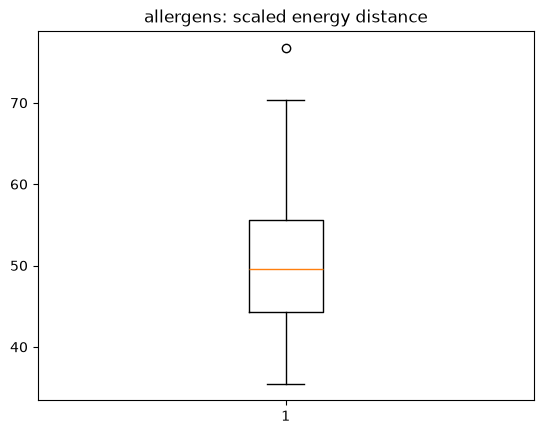

In [44]:
plt.boxplot(energy_distance_gmm_scaled)
plt.title(f'{datasets[i]}: scaled energy distance')
plt.show()